### 1) Import Pandas and Numpy

In [1]:
#your code here
import pandas as pd
import numpy as np


### 2) Import the dataset and  Assign it to a variable called Chipo

#### Import the dataset from
https://github.com/justmarkham/pandas-videos/blob/master/data/chipotle.tsv

#### REMEMBER: It is a .tsv file , you will have to do some research on how to read .tsv files first!

In [2]:
#your code here
!wget -O mytable.tsv "https://raw.githubusercontent.com/justmarkham/pandas-videos/refs/heads/master/data/chipotle.tsv"
chipo=pd.read_table("mytable.tsv")
chipo.head()

--2026-06-15 15:54:41--  https://raw.githubusercontent.com/justmarkham/pandas-videos/refs/heads/master/data/chipotle.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 364975 (356K) [text/plain]
Saving to: ‘mytable.tsv’

mytable.tsv         100%[===================>] 356.42K  --.-KB/s    in 0.03s   

2026-06-15 15:54:41 (13.2 MB/s) - ‘mytable.tsv’ saved [364975/364975]



,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98


### 3) See the first 10 entries

In [3]:
#your code here
chipo.head(10)

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


### 4) What is the number of observations in the dataset?

In [4]:
#your code here
chipo.shape[0]

4622

### 5) What is the number of columns in the dataset?

In [5]:
#your code here
chipo.shape[1]

5

### 6) Print the name of all the columns.

In [6]:
#your code here
chipo.columns.tolist()

['order_id', 'quantity', 'item_name', 'choice_description', 'item_price']

### 7) Which was the most-ordered item?

In [18]:
#your code here
chipo.item_name.value_counts().idxmax()


'Chicken Bowl'

### 8) For the most-ordered item, how many items were ordered?

In [19]:
#your code here
chipo.groupby('item_name')['quantity'].sum().max()

761

### 9) What was the most ordered item in the choice_description column?

In [9]:
#your code here
chipo.choice_description.value_counts().idxmax()

'[Diet Coke]'

### 10) How many items were ordered in total?

In [10]:
#your code here
chipo.quantity.sum()

np.int64(4972)

### 11) Turn the item price into a float

In [11]:
#your code here
chipo.item_price=chipo.item_price.str.replace('$',"").astype(float)
chipo.item_price

,item_price
0,2.39
1,3.39
2,3.39
3,2.39
4,16.98
...,...
4617,11.75
4618,11.75
4619,11.25
4620,8.75


### 12) How much was the revenue for the period in the dataset?
#### Revenue will be the sum of quantity * item_price!

In [21]:
#your code here
print((chipo.quantity*chipo.item_price).sum())

39237.02


### 13) How many orders were made in the period?

In [13]:
#your code here
chipo.order_id.nunique()

1834

### 14) What is the average revenue amount per order?

In [22]:
#your code here
#first total revenue
total_revenue=(chipo.quantity*chipo.item_price).sum()

#then the total number of orders
total_orders=chipo.order_id.nunique()

print(total_revenue/total_orders)

21.39423118865867


### 15) How many different items are sold?

In [15]:

chipo.item_name.nunique()
#your code here

50

### 16) Show a histogram with number of orders with bill on the x-axis.

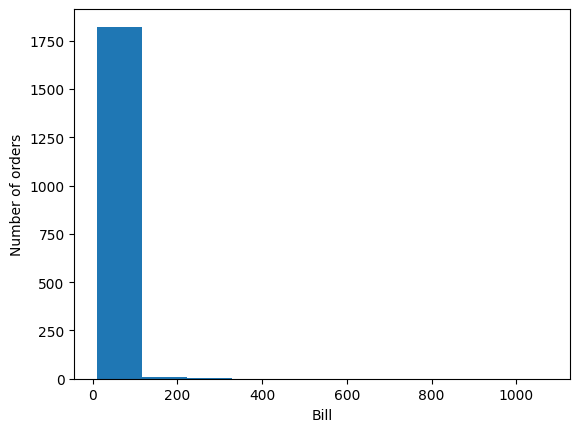

In [24]:
#so first find the uid and total bill of each
order=(chipo.quantity*chipo.item_price).groupby(chipo.order_id).sum()
import matplotlib.pyplot as plt
plt.hist(order)
plt.xlabel('Bill')
plt.ylabel('Number of orders')
plt.show()